In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, confusion_matrix, classification_report)


In [11]:
# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [13]:
# Clustering
from sklearn.cluster import KMeans

In [14]:
# NLP
import re
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [15]:
# !pip install nltk
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer


In [16]:
# Download stopwords if not already
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [17]:
# For nicer plots
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [18]:
# 2. LOAD DATA (Numeric/Categorical Dataset, e.g. forestfires.csv)


In [20]:
data = pd.read_csv(r'C:\Users\ADMIN\OneDrive\Desktop\forestfires.csv')


In [21]:
data

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.00
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.00
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.00
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.00
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00


In [29]:
print("Shape of data:", data.shape)
print("\nFirst 5 rows:")
print(data.head())

Shape of data: (517, 13)

First 5 rows:
   X  Y month  day  FFMC   DMC     DC  ISI  temp  RH  wind  rain  area
0  7  5   mar  fri  86.2  26.2   94.3  5.1   8.2  51   6.7   0.0   0.0
1  7  4   oct  tue  90.6  35.4  669.1  6.7  18.0  33   0.9   0.0   0.0
2  7  4   oct  sat  90.6  43.7  686.9  6.7  14.6  33   1.3   0.0   0.0
3  8  6   mar  fri  91.7  33.3   77.5  9.0   8.3  97   4.0   0.2   0.0
4  8  6   mar  sun  89.3  51.3  102.2  9.6  11.4  99   1.8   0.0   0.0


In [30]:
# BASIC EDA
print("\nInfo:")
print(data.info())

print("\nDescribe (numeric):")
print(data.describe())

print("\nMissing values:")
print(data.isnull().sum())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB
None

Describe (numeric):
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
s

In [33]:
# Check unique values in each column (useful for categorical)
print("\nUnique values per column:")
for col in data.columns:
    print(col, "->", data[col].nunique())



Unique values per column:
X -> 9
Y -> 7
month -> 12
day -> 7
FFMC -> 106
DMC -> 215
DC -> 219
ISI -> 119
temp -> 192
RH -> 75
wind -> 21
rain -> 7
area -> 251


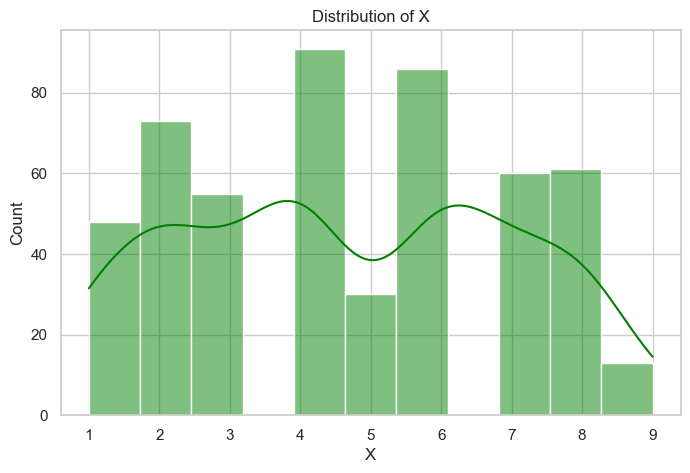

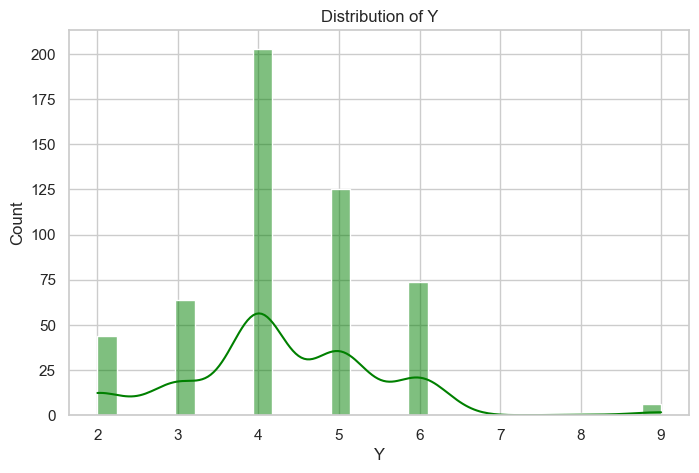

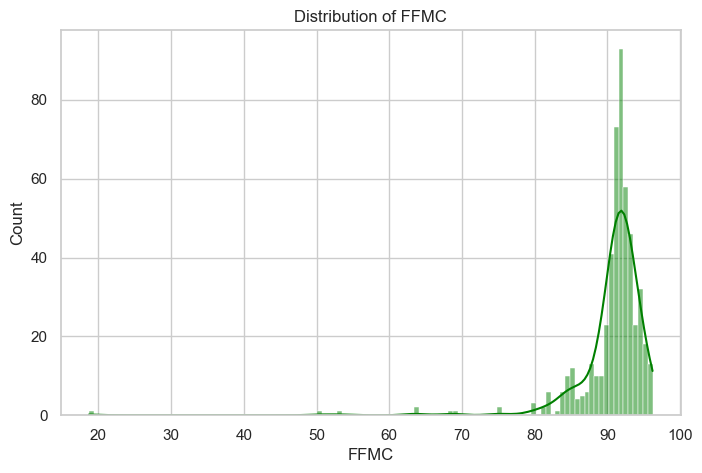

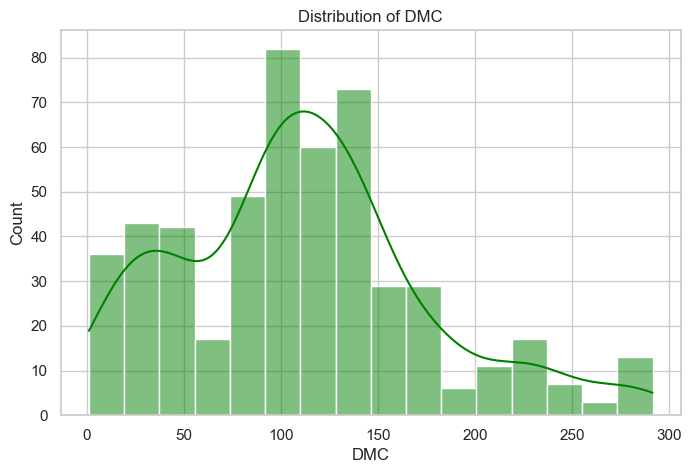

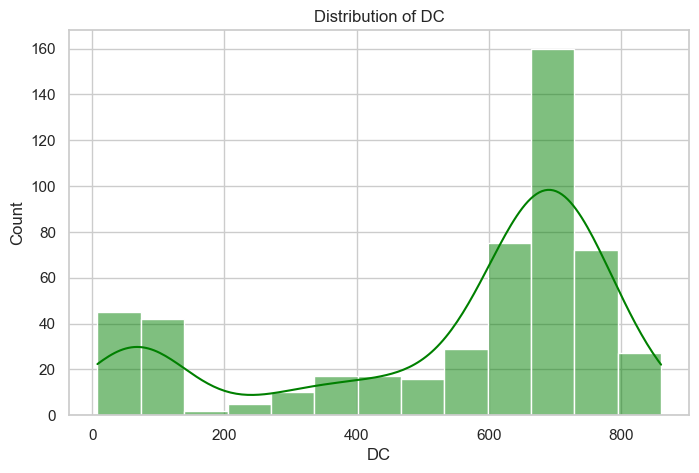

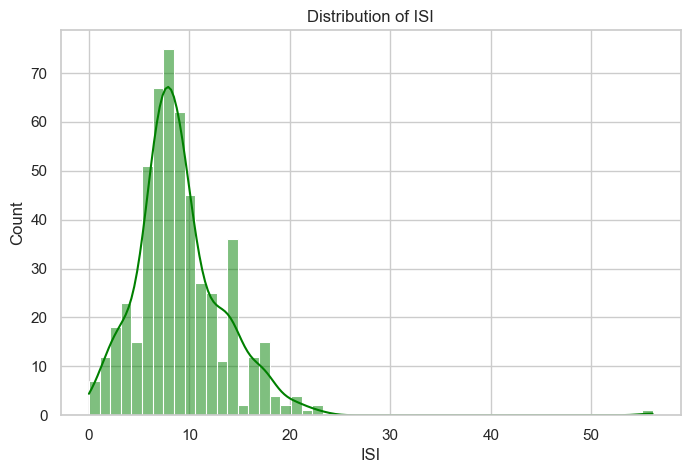

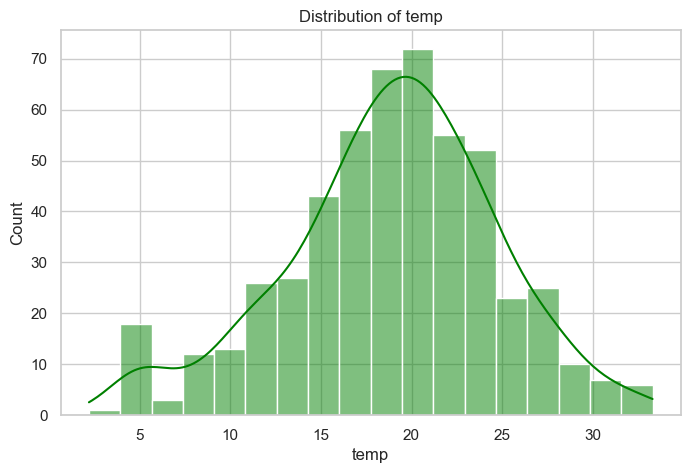

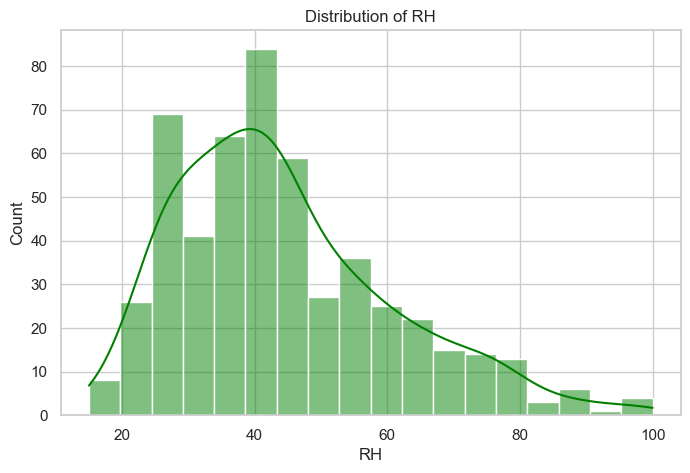

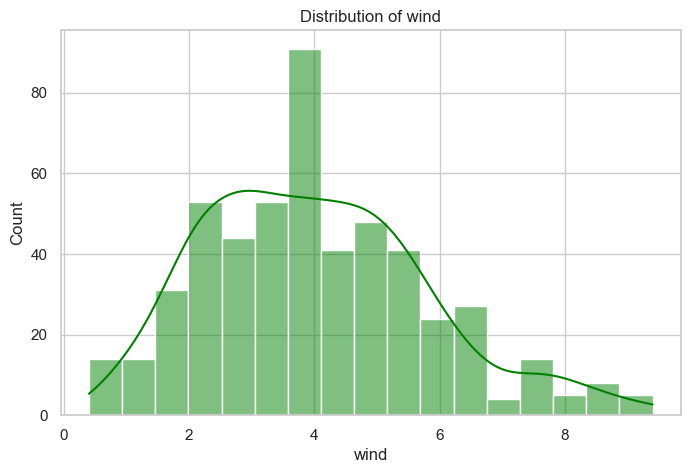

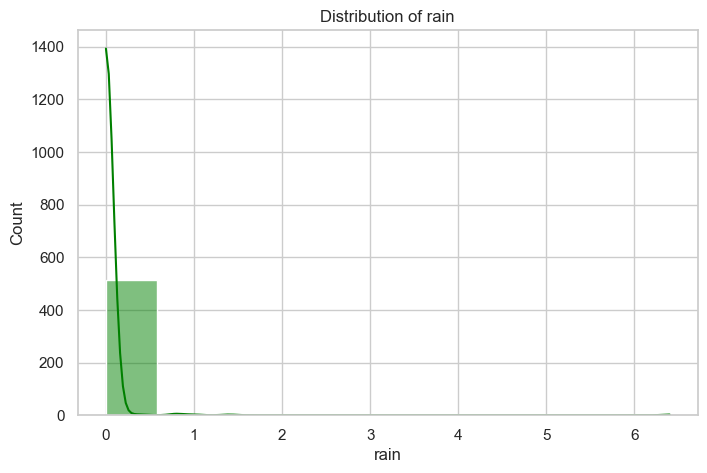

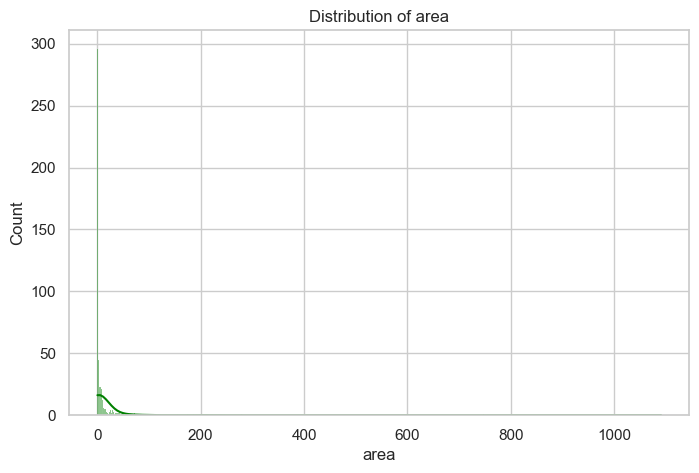

In [43]:
# 4. DATA VISUALISATION (EDA PLOTS)
# Histograms for numeric columns
numeric_cols = data.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    plt.figure()
    sns.histplot(data[col], kde=True, color='green')
    plt.title(f"Distribution of {col}")
    plt.show()

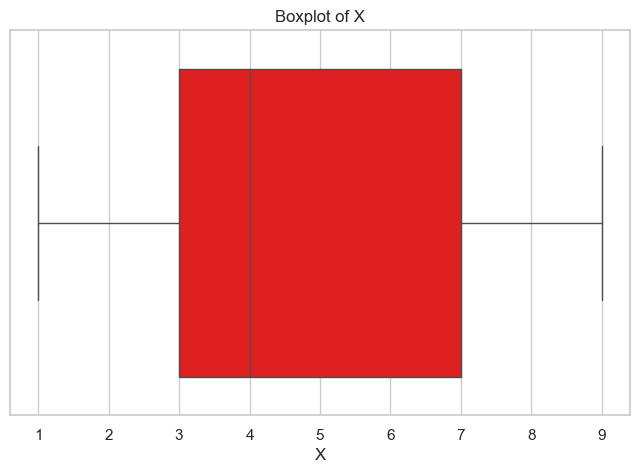

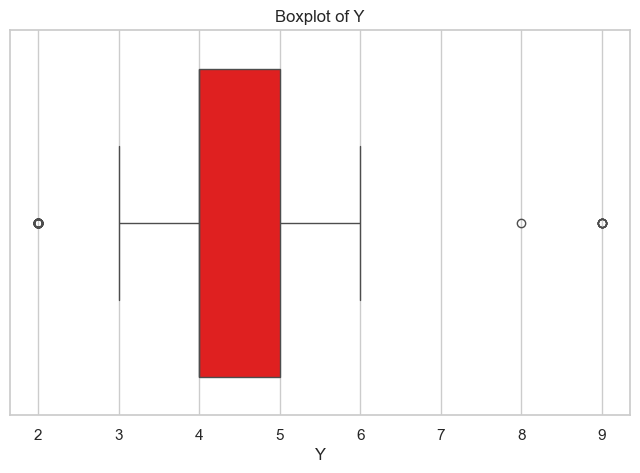

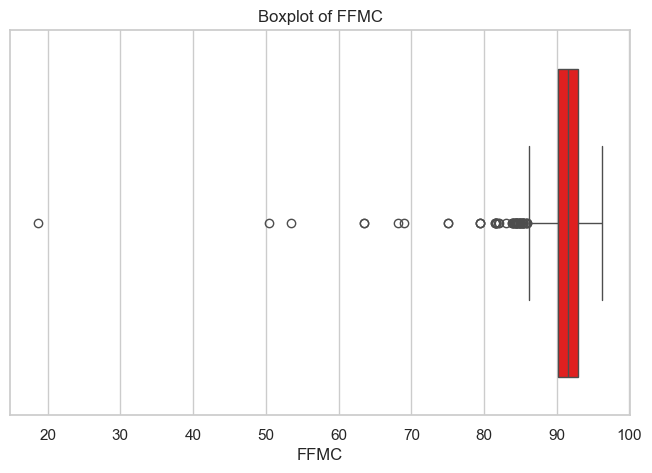

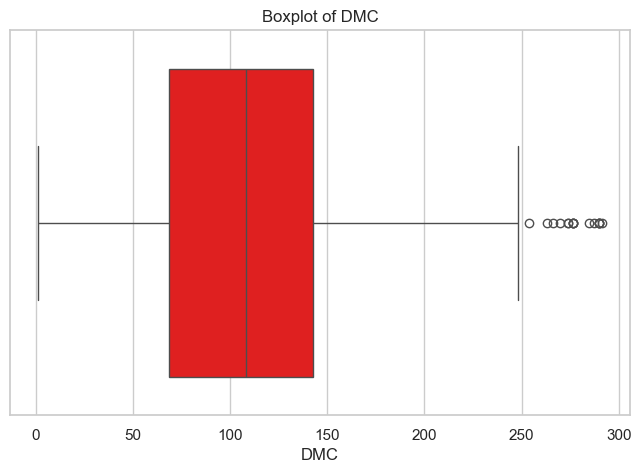

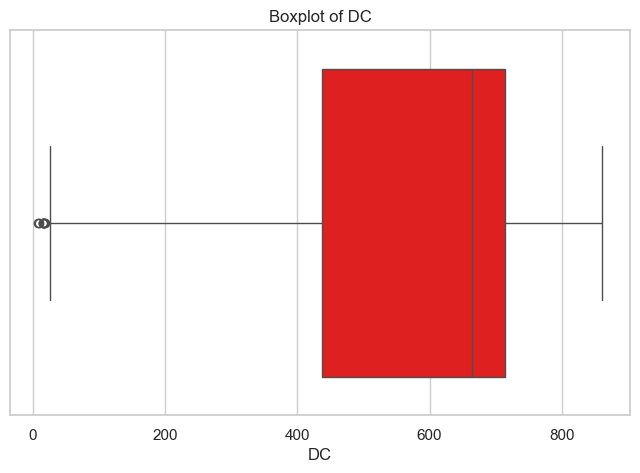

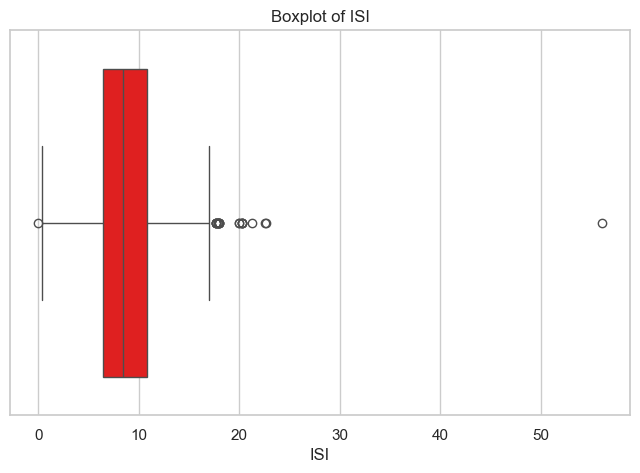

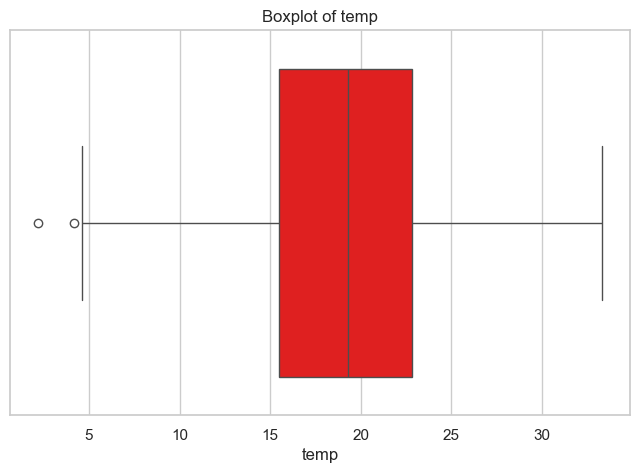

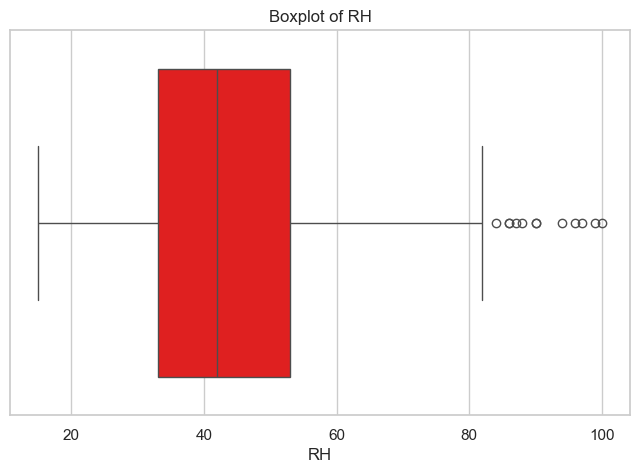

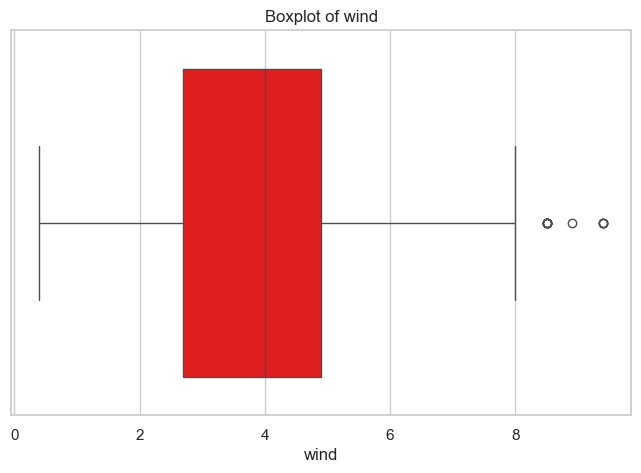

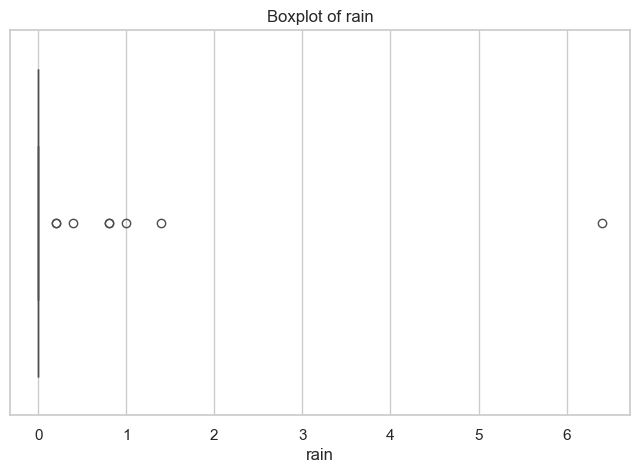

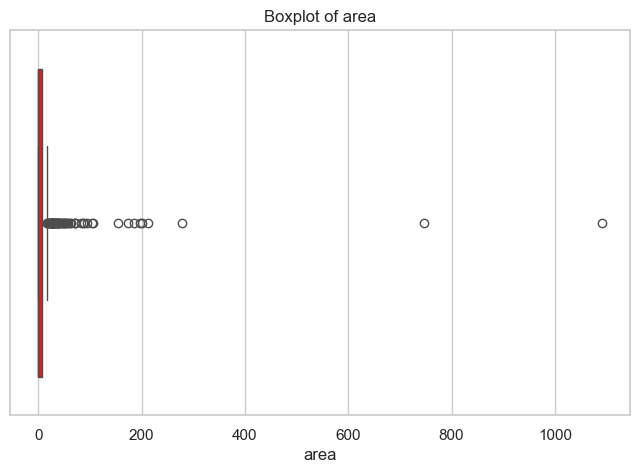

In [44]:
# Boxplots for numeric columns
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=data[col], color='red')
    plt.title(f"Boxplot of {col}")
    plt.show()


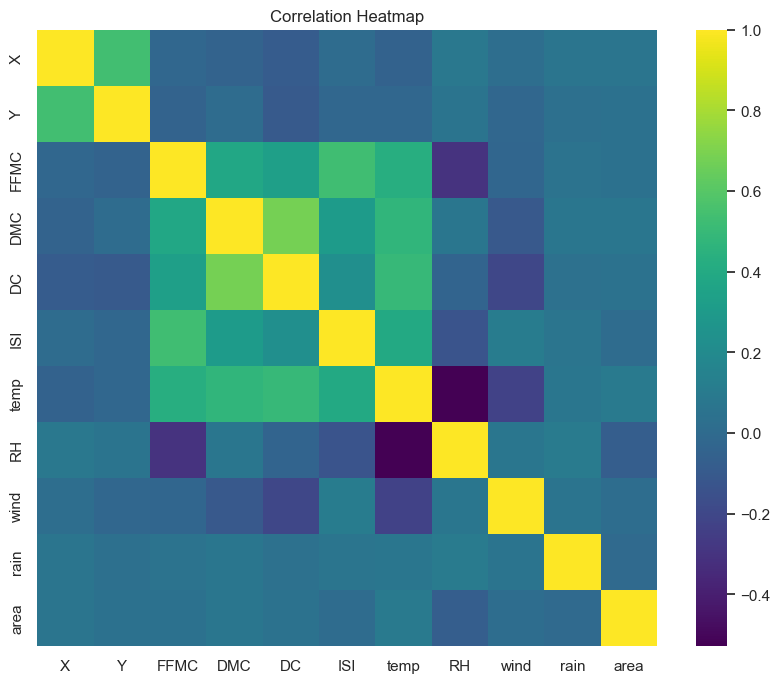

In [48]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = data[numeric_cols].corr()
sns.heatmap(corr, annot=False, cmap="viridis")
plt.title("Correlation Heatmap")
plt.show()

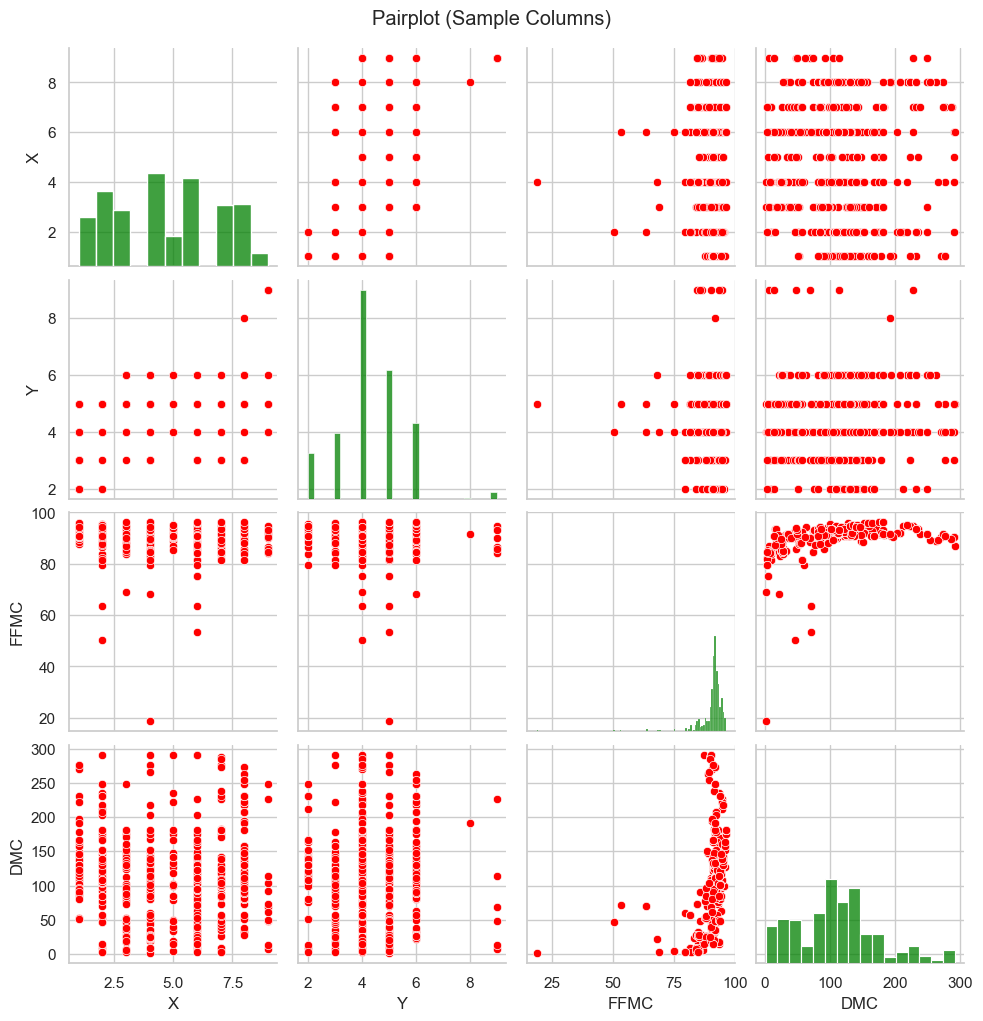

In [62]:
# Pairplot for a few important numeric columns (to avoid being too heavy)
sample_numeric_cols = numeric_cols[:4]  # first 4 numeric columns
sns.pairplot(data[sample_numeric_cols], plot_kws={'color':'red'},diag_kws={'color':'green'})
plt.suptitle("Pairplot (Sample Columns)", y=1.02)
plt.show()

In [66]:
#5.DATA PREPROCESSING
#  Example: Regression Target = 'area' (forestfires dataset)

In [68]:
# Assume 'area' is the target for regression
target_reg = 'area'  # change if your dataset is different


In [69]:
# Handle categorical variables: 'month', 'day' (specific to forestfires)
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
print("\nCategorical columns:", categorical_cols)


Categorical columns: ['month', 'day']


In [70]:
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)


In [71]:
X_reg = data_encoded.drop(target_reg, axis=1)
y_reg = data_encoded[target_reg]

In [73]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

In [76]:
# Import the StandardScaler class from scikit-learn
from sklearn.preprocessing import StandardScaler

# Scale numeric features for some models
scaler = StandardScaler()
X_reg_train_scaled = scaler.fit_transform(X_reg_train)
X_reg_test_scaled = scaler.transform(X_reg_test)

In [77]:
# REGRESSION MODELS (Linear, Ridge, Lasso)

def evaluate_regression_model(model, X_train, X_test, y_train, y_test, name="Model"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

In [84]:
# Define the 'name' variable before using it in the f-string
name = "Model"  # Replace with your actual model name or variable

# Define rmse and r2 variables before using them
rmse = 0.25  # Replace with your actual RMSE value or calculation
r2 = 0.85    # Replace with your actual R² value or calculation

print(f"\n{name} Results")
print("-" * 30)
print("rmse:", rmse)
print("r2_ Score:", r2)


Model Results
------------------------------
rmse: 0.25
r2_ Score: 0.85


In [85]:
# Linear Regression
lin_reg = LinearRegression()
evaluate_regression_model(
    lin_reg, X_reg_train_scaled, X_reg_test_scaled, y_reg_train, y_reg_test, "Linear Regression")

In [86]:
# Ridge Regression (L2)
ridge_reg = Ridge(alpha=1.0)
evaluate_regression_model(
    ridge_reg, X_reg_train_scaled, X_reg_test_scaled, y_reg_train, y_reg_test, "Ridge Regression")

In [87]:
# Lasso Regression (L1)
lasso_reg = Lasso(alpha=0.01)
evaluate_regression_model(
    lasso_reg, X_reg_train_scaled, X_reg_test_scaled, y_reg_train, y_reg_test, "Lasso Regression")


In [88]:
#CLASSIFICATION MODELS
#Create a binary target, e.g. large_fire = 1 if area > threshold
# Define binary target
threshold = 0  # here: fire occurred (area > 0) vs no fire; change as needed
data_class = data_encoded.copy()
data_class['fire_occurred'] = (data_class[target_reg] > threshold).astype(int)

In [89]:
X_clf = data_class.drop([target_reg, 'fire_occurred'], axis=1)
y_clf = data_class['fire_occurred']

In [90]:
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

In [91]:
X_clf_train_scaled = scaler.fit_transform(X_clf_train)
X_clf_test_scaled = scaler.transform(X_clf_test)

In [92]:
def evaluate_classification_model(model, X_train, X_test, y_train, y_test, name="Model"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

In [137]:
# Import necessary libraries
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

y_test = np.array([0, 1, 0, 1, 0, 1, 0, 1])  # True labels
y_pred = np.array([0, 1, 0, 0, 0, 1, 1, 1])  # Predicted labels
name = "Sample Model"  # Define the model name
acc = accuracy_score(y_test, y_pred)
print(f"\n{name} Results")
print("-" * 30)
print("Accuracy:", acc)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Sample Model Results
------------------------------
Accuracy: 0.75

Confusion Matrix:
 [[3 1]
 [1 3]]

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.75      0.75         4
           1       0.75      0.75      0.75         4

    accuracy                           0.75         8
   macro avg       0.75      0.75      0.75         8
weighted avg       0.75      0.75      0.75         8



In [100]:
#Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
evaluate_classification_model(
log_reg, X_clf_train_scaled, X_clf_test_scaled, y_clf_train, y_clf_test, "Logistic Regression")



In [101]:
# K-Nearest Neighbors (KNN)
knn = KNeighborsClassifier(n_neighbors=5)
evaluate_classification_model(
    knn, X_clf_train_scaled, X_clf_test_scaled, y_clf_train, y_clf_test, "KNN Classifier")

In [102]:
#K-Nearest Neighbors (KNN)
knn = KNeighborsClassifier(n_neighbors=5)
evaluate_classification_model(
    knn, X_clf_train_scaled, X_clf_test_scaled, y_clf_train, y_clf_test, "KNN Classifier")



In [103]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
evaluate_classification_model(
    rf, X_clf_train, X_clf_test, y_clf_train, y_clf_test, "Random Forest Classifier")


In [105]:
#Support Vector Machine (SVM)
svm_clf = SVC(kernel='rbf')   # or 'linear'
evaluate_classification_model(
    svm_clf, X_clf_train_scaled, X_clf_test_scaled, y_clf_train, y_clf_test, "SVM Classifier")

In [106]:
#Naive Bayes (GaussianNB)
nb = GaussianNB()
evaluate_classification_model(
nb, X_clf_train, X_clf_test, y_clf_train, y_clf_test, "Naive Bayes Classifier")

In [108]:
# UNSUPERVISED LEARNING: KMEANS CLUSTERING

# Use only numeric features, scaled
X_cluster = data_encoded.drop(target_reg, axis=1)
X_cluster_scaled = scaler.fit_transform(X_cluster)

In [110]:
# Choose number of clusters (k)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster_scaled)

In [111]:
data_encoded['cluster'] = clusters
print("\nCluster counts:")
print(data_encoded['cluster'].value_counts())


Cluster counts:
cluster
2    230
1    186
0    101
Name: count, dtype: int64


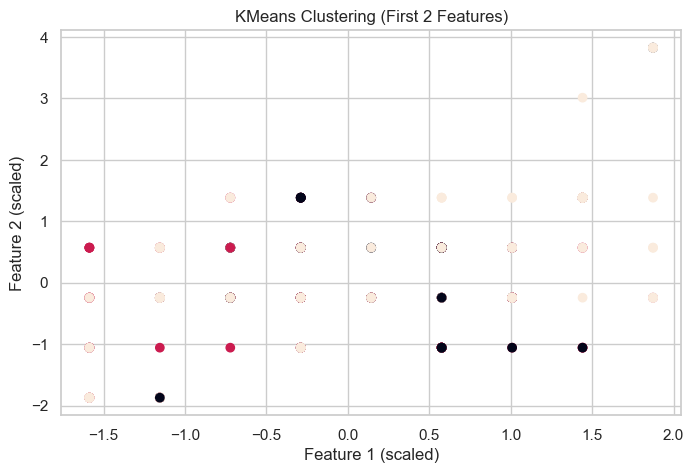

In [113]:
# Visualize clustering on 2D using 2 features (e.g. first two numeric features)
plt.figure()
plt.scatter(X_cluster_scaled[:, 0], X_cluster_scaled[:, 1], c=clusters)
plt.title("KMeans Clustering (First 2 Features)")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.show()



In [117]:
# BASIC NLP PIPELINE (TEXT DATA + ML MODEL)
# Example small text dataset (you can replace with your own)
texts =[
"I love this product, it works great!",
"This is the worst service I have ever used.",
"Absolutely fantastic experience, highly recommend.",
"Terrible, I will never come back again.",
"Good quality and fast delivery.",
"Bad quality, very disappointed."]

In [118]:
# Labels: 1 = positive, 0 = negative (for example)
labels = [1, 0, 1, 0, 1, 0]
y_text = np.array(labels)


# 9.1 Text cleaning function
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)   # remove punctuation and numbers
    return text

cleaned_texts = [clean_text(t) for t in texts]



In [119]:
#Remove stopwords and optional stemming
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

In [120]:
def preprocess_tokens(text):
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]    # remove stopwords
    tokens = [stemmer.stem(t) for t in tokens]             # stemming
    return " ".join(tokens)

In [121]:
processed_texts = [preprocess_tokens(t) for t in cleaned_texts]
print("\nProcessed texts:")
for t in processed_texts:
    print(t)


Processed texts:
love product work great
worst servic ever use
absolut fantast experi highli recommend
terribl never come back
good qualiti fast deliveri
bad qualiti disappoint


In [130]:
# TF-IDF
tfidf_vec = TfidfVectorizer()
X_text_tfidf = tfidf_vec.fit_transform(processed_texts)


In [131]:
# Use TF-IDF features for classification
X_text = X_text_tfidf


In [133]:
X_text_train, X_text_test, y_text_train, y_text_test = train_test_split(
    X_text, y_text, test_size=0.3, random_state=42, stratify=y_text)

In [134]:
#rain a simple classifier on text (Logistic Regression)
text_clf = LogisticRegression(max_iter=1000)
text_clf.fit(X_text_train, y_text_train)

LogisticRegression(max_iter=1000)

In [135]:
y_text_pred = text_clf.predict(X_text_test)
print("\nNLP Text Classification Results (Logistic Regression)")
print("-" * 50)
print("Accuracy:", accuracy_score(y_text_test, y_text_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_text_test, y_text_pred))
print("\nClassification Report:\n", classification_report(y_text_test, y_text_pred))


NLP Text Classification Results (Logistic Regression)
--------------------------------------------------
Accuracy: 0.5

Confusion Matrix:
 [[0 1]
 [0 1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [136]:
#END